# Responsible Credit Scoring
## Predictive Risk Modeling & Ethical Fairness Auditing
### Student: Carlos Elizondo
### Student Number: 500890062
### Supervisor: Tamer Abdou
**Toronto Metropolitan University**

## 1. Setup & Load

Import the libraries needed for data handling, visualization, and modeling, then mounting Google
Drive and loading the master feature matrix produced by the feature selection and relational
aggregation notebook.

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report
)
from scipy.stats import pointbiserialr, chi2_contingency

RANDOM_STATE = 42

In [2]:
# Mount Drive and load the master feature matrix
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/CIND820_Project/master_feature_matrix.csv'
df = pd.read_csv(DATA_PATH)

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nClass balance:")
print(df['TARGET'].value_counts(normalize=True).round(3))

Mounted at /content/drive
Loaded: 307,511 rows x 66 columns

Class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


## 2. Data Quality Checks

Before touching the data, i want to confirm it's structurally sound: no duplicate records, no duplicate
applicant IDs, and identify exactly which columns have missing values and how much.

In [3]:
#Checking master feature matrix to see what types are in each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 66 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   SK_ID_CURR                  307511 non-null  int64  
 1   TARGET                      307511 non-null  int64  
 2   CODE_GENDER                 307511 non-null  object 
 3   DAYS_BIRTH                  307511 non-null  int64  
 4   AMT_INCOME_TOTAL            307511 non-null  float64
 5   AMT_CREDIT                  307511 non-null  float64
 6   AMT_ANNUITY                 307499 non-null  float64
 7   AMT_GOODS_PRICE             307233 non-null  float64
 8   NAME_CONTRACT_TYPE          307511 non-null  object 
 9   DAYS_EMPLOYED               252137 non-null  float64
 10  DAYS_REGISTRATION           307511 non-null  float64
 11  DAYS_ID_PUBLISH             307511 non-null  int64  
 12  OCCUPATION_TYPE             211120 non-null  object 
 13  ORGANIZATION_T

In [4]:
#printing out first 5 rows to see some of the variables inside the master feature matrix
df.head()


,SK_ID_CURR,TARGET,CODE_GENDER,DAYS_BIRTH,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_CONTRACT_TYPE,DAYS_EMPLOYED,...,POS_AVG_COMPLETION_RATIO,CC_AVG_UTILIZATION,CC_MAX_DPD,CC_AVG_PAYMENT_RATIO,CC_TOTAL_CARDS,RATIO_DEBT_TO_INCOME,RATIO_ANNUITY_TO_INCOME,RATIO_CREDIT_TO_GOODS,AGE_YEARS,EMPLOYED_YEARS
0,100002,1,M,-9461,202500.0,406597.5,24700.5,351000.0,Cash loans,-637.0,...,0.375000,NaN,NaN,NaN,NaN,2.007889,0.121978,1.158397,25.920548,1.745205
1,100003,0,F,-16765,270000.0,1293502.5,35698.5,1129500.0,Cash loans,-1188.0,...,0.455357,NaN,NaN,NaN,NaN,4.790750,0.132217,1.145199,45.931507,3.254795
2,100004,0,M,-19046,67500.0,135000.0,6750.0,135000.0,Revolving loans,-225.0,...,0.437500,NaN,NaN,NaN,NaN,2.000000,0.100000,1.000000,52.180822,0.616438
3,100006,0,F,-19005,135000.0,312682.5,29686.5,297000.0,Cash loans,-3039.0,...,0.429167,0.0,0.0,NaN,1.0,2.316167,0.219900,1.052803,52.068493,8.326027
4,100007,0,M,-19932,121500.0,513000.0,21865.5,513000.0,Cash loans,-3038.0,...,0.442439,NaN,NaN,NaN,NaN,4.222222,0.179963,1.000000,54.608219,8.323288


In [5]:
# Duplicate check
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate SK_ID_CURR:", df['SK_ID_CURR'].duplicated().sum())

Exact duplicate rows: 0
Duplicate SK_ID_CURR: 0


## 3. Handling Missing Values

No column is imputed the same way — the fill strategy depends on *why* the value is missing:

- **Occupation type:** applicants with no employment history are labeled "Not_Employed";
  applicants who are employed but didn't have an occupation recorded are filled with the most
  common occupation for their education level.
- **Behavioral history columns** (credit card, bureau, previous application, installment, and
  POS/cash aggregates): a missing value here means the applicant has no record in that source
  table at all — not a random gap. These are filled with 0 and given a companion flag column so
  the model can tell "genuinely zero" apart from "no history to measure."
- **External credit bureau scores (EXT_SOURCE_1/2/3):** filled with the median, plus a flag,
  since a missing score likely means the external source had no data on this applicant.
- **Employment length:** filled with 0 and flagged, since missing here means not
  currently employed, not "zero experience."
- **Remaining small-missingness numeric columns** (each under 0.5% missing): filled with the
  plain median, no flag needed.
- Four rows with an unspecified/unknown gender value were dropped as too small a group to model meaningfully.

In [6]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print(missing[missing['Missing %'] > 0])

                            Missing Count  Missing %
CC_AVG_PAYMENT_RATIO               248242      80.73
CC_AVG_UTILIZATION                 221475      72.02
CC_MAX_DPD                         220606      71.74
CC_TOTAL_CARDS                     220606      71.74
BURBAL_TOTAL_MONTHS                215280      70.01
BURBAL_MONTHS_CLOSED               215280      70.01
BURBAL_MONTHS_OVERDUE              215280      70.01
EXT_SOURCE_1                       173378      56.38
BUR_MAX_OVERDUE_AMT                123625      40.20
OCCUPATION_TYPE                     96391      31.35
EXT_SOURCE_3                        60965      19.83
DAYS_EMPLOYED                       55374      18.01
EMPLOYED_YEARS                      55374      18.01
BUR_AVG_UTILIZATION                 52634      17.12
BUR_TOTAL_DEBT                      51380      16.71
BUR_ACTIVE_LOANS                    44020      14.31
BUR_AVG_DAYS_OVERDUE                44020      14.31
BUR_TOTAL_LOANS                     44020     

In [7]:
# How many applicants have zero or missing income?
print("Rows with AMT_INCOME_TOTAL == 0:", (df['AMT_INCOME_TOTAL'] == 0).sum())
print("Rows with AMT_INCOME_TOTAL missing:", df['AMT_INCOME_TOTAL'].isnull().sum())
print("Min income value:", df['AMT_INCOME_TOTAL'].min())

Rows with AMT_INCOME_TOTAL == 0: 0
Rows with AMT_INCOME_TOTAL missing: 0
Min income value: 25650.0


In [8]:
# Does missing OCCUPATION_TYPE line up with missing EMPLOYED_YEARS (i.e. not employed)?
occ_missing = df['OCCUPATION_TYPE'].isnull()
emp_missing = df['EMPLOYED_YEARS'].isnull()

print("OCCUPATION_TYPE missing:", occ_missing.sum())
print("EMPLOYED_YEARS missing:", emp_missing.sum())
print("Missing in BOTH:", (occ_missing & emp_missing).sum())
print("OCCUPATION_TYPE missing but EMPLOYED_YEARS present:", (occ_missing & ~emp_missing).sum())

OCCUPATION_TYPE missing: 96391
EMPLOYED_YEARS missing: 55374
Missing in BOTH: 55372
OCCUPATION_TYPE missing but EMPLOYED_YEARS present: 41019


In [9]:
# Step 1: Not employed -> explicit category
not_employed_mask = df['EMPLOYED_YEARS'].isnull()
df.loc[not_employed_mask, 'OCCUPATION_TYPE'] = 'Not_Employed'

print(f"Filled as Not_Employed: {not_employed_mask.sum()}")
print(f"Still missing after step 1: {df['OCCUPATION_TYPE'].isnull().sum()}")

Filled as Not_Employed: 55374
Still missing after step 1: 41019


In [10]:
# Step 2: Employed but occupation missing -> mode occupation within their education group
edu_to_occ_mode = (
    df[df['OCCUPATION_TYPE'].notnull()]
    .groupby('NAME_EDUCATION_TYPE')['OCCUPATION_TYPE']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

print("Mode occupation per education level:")
for edu, occ in edu_to_occ_mode.items():
    print(f"  {edu}: {occ}")

still_missing = df['OCCUPATION_TYPE'].isnull()
df.loc[still_missing, 'OCCUPATION_TYPE'] = df.loc[still_missing, 'NAME_EDUCATION_TYPE'].map(edu_to_occ_mode)

print(f"\nRemaining missing OCCUPATION_TYPE: {df['OCCUPATION_TYPE'].isnull().sum()}")

Mode occupation per education level:
  Academic degree: Managers
  Higher education: Core staff
  Incomplete higher: Laborers
  Lower secondary: Not_Employed
  Secondary / secondary special: Laborers

Remaining missing OCCUPATION_TYPE: 0


In [11]:
# Group 1: "No history" behavioral aggregates -> fill 0 + add a missingness flag
# NaN here means "no record in that source table" (thin-file), not a random gap

group1_cols = [
    'CC_AVG_PAYMENT_RATIO', 'CC_AVG_UTILIZATION', 'CC_MAX_DPD', 'CC_TOTAL_CARDS',
    'BURBAL_TOTAL_MONTHS', 'BURBAL_MONTHS_CLOSED', 'BURBAL_MONTHS_OVERDUE',
    'BUR_MAX_OVERDUE_AMT', 'BUR_AVG_UTILIZATION', 'BUR_TOTAL_DEBT', 'BUR_ACTIVE_LOANS',
    'BUR_AVG_DAYS_OVERDUE', 'BUR_TOTAL_LOANS', 'BUR_TOTAL_PROLONGED',
    'PREV_AVG_ANNUITY', 'PREV_AVG_CREDIT_AMT', 'PREV_COUNT_REFUSED', 'PREV_TOTAL_APPS',
    'PREV_COUNT_APPROVED', 'PREV_APPROVAL_RATE',
    'INST_TOTAL_RECORDS', 'INST_COUNT_LATE', 'INST_MAX_DAYS_PAST_DUE',
    'INST_AVG_PAYMENT_DELAY', 'INST_RATIO_LATE', 'INST_AVG_UNDERPAYMENT',
    'POS_MONTHS_DPD_GT0', 'POS_MAX_DPD', 'POS_AVG_DPD', 'POS_AVG_COMPLETION_RATIO',
    'AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT'
]

for col in group1_cols:
    flag_col = f'FLAG_MISSING_{col}'
    df[flag_col] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(0)

print(f"Processed {len(group1_cols)} columns.")
print(f"Remaining NaNs in these columns: {df[group1_cols].isnull().sum().sum()}")
print(f"\nExample flag column created: FLAG_MISSING_CC_AVG_UTILIZATION")
print(df['FLAG_MISSING_CC_AVG_UTILIZATION'].value_counts())

Processed 33 columns.
Remaining NaNs in these columns: 0

Example flag column created: FLAG_MISSING_CC_AVG_UTILIZATION
FLAG_MISSING_CC_AVG_UTILIZATION
1    221475
0     86036
Name: count, dtype: int64


In [12]:
# EXT_SOURCE_1/2/3: external credit bureau scores
# Missing likely means the external source had no data on this applicant —
# median impute (not 0, which would falsely look like "worst possible score"),
# plus a flag since the absence itself is informative (thin external file)

ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

for col in ext_source_cols:
    flag_col = f'FLAG_MISSING_{col}'
    df[flag_col] = df[col].isnull().astype(int)
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median {median_val:.4f}")

print(f"\nRemaining NaNs: {df[ext_source_cols].isnull().sum().sum()}")

EXT_SOURCE_1: filled with median 0.5060
EXT_SOURCE_2: filled with median 0.5660
EXT_SOURCE_3: filled with median 0.5353

Remaining NaNs: 0


In [13]:
# DAYS_EMPLOYED / EMPLOYED_YEARS: missing means not employed (retired/unemployed)
# Fill with 0 + flag rather than median, since "median years employed" would
# misrepresent someone who isn't employed at all

for col in ['DAYS_EMPLOYED', 'EMPLOYED_YEARS']:
    flag_col = f'FLAG_MISSING_{col}'
    df[flag_col] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(0)

print(f"Remaining NaNs: {df[['DAYS_EMPLOYED', 'EMPLOYED_YEARS']].isnull().sum().sum()}")

Remaining NaNs: 0


In [14]:
# Remaining small-missingness numeric columns: plain median fill, no flag needed
# (each under 0.5% missing, including AMT_ANNUITY and CNT_FAM_MEMBERS which were
# too small to show up in the earlier missing-value printout)

small_missing_cols = [
    'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'RATIO_CREDIT_TO_GOODS', 'AMT_GOODS_PRICE',
    'AMT_ANNUITY', 'CNT_FAM_MEMBERS'
]

for col in small_missing_cols:
    n_missing = df[col].isnull().sum()
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {n_missing} missing with median {median_val:.4f}")

# RATIO_ANNUITY_TO_INCOME depends on AMT_ANNUITY, so recompute any leftover NaNs there now that AMT_ANNUITY is filled
if df['RATIO_ANNUITY_TO_INCOME'].isnull().sum() > 0:
    df['RATIO_ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
    print(f"Recomputed RATIO_ANNUITY_TO_INCOME, remaining NaNs: {df['RATIO_ANNUITY_TO_INCOME'].isnull().sum()}")

DEF_30_CNT_SOCIAL_CIRCLE: filled 1021 missing with median 0.0000
DEF_60_CNT_SOCIAL_CIRCLE: filled 1021 missing with median 0.0000
RATIO_CREDIT_TO_GOODS: filled 278 missing with median 1.1188
AMT_GOODS_PRICE: filled 278 missing with median 450000.0000
AMT_ANNUITY: filled 12 missing with median 24903.0000
CNT_FAM_MEMBERS: filled 2 missing with median 2.0000
Recomputed RATIO_ANNUITY_TO_INCOME, remaining NaNs: 0


In [15]:
# Final check: confirm zero missing values anywhere in the dataframe
final_missing = df.isnull().sum()
final_missing = final_missing[final_missing > 0]

if len(final_missing) == 0:
    print("All missing values resolved.")
else:
    print("Columns still with missing values:")
    print(final_missing)

All missing values resolved.


## 4. Encoding Categorical Variables

Machine learning models need numbers, not text, so every categorical column is converted:

- **Binary categories** (gender, loan contract type, car ownership, property ownership) are
  mapped directly to 0/1.
- **Education level** has a genuine order from lowest to highest, so it's ranked 0–4 instead of
  one-hot encoded, preserving that order for the model.
- **Remaining multi-category columns with no natural order** (occupation, organization type,
  income type, family status, housing type) are one-hot encoded, turning each category into its
  own 0/1 column so the model doesn't mistake them for having a ranked relationship.

In [16]:
# Simple binary encodings: no inherent order, just need numbers for the model to split on
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})
df['NAME_CONTRACT_TYPE'] = df['NAME_CONTRACT_TYPE'].map({'Cash loans': 0, 'Revolving loans': 1})
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'N': 0, 'Y': 1})
df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'N': 0, 'Y': 1})

print(df[['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']].head())
print("\nAny NaNs introduced by mapping (would mean an unexpected category slipped through):")
print(df[['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']].isnull().sum())

   CODE_GENDER  NAME_CONTRACT_TYPE  FLAG_OWN_CAR  FLAG_OWN_REALTY
0          0.0                   0             0                1
1          1.0                   0             0                0
2          0.0                   1             1                1
3          1.0                   0             0                1
4          0.0                   0             0                1

Any NaNs introduced by mapping (would mean an unexpected category slipped through):
CODE_GENDER           4
NAME_CONTRACT_TYPE    0
FLAG_OWN_CAR          0
FLAG_OWN_REALTY       0
dtype: int64


In [17]:
# NAME_EDUCATION_TYPE has a genuine order (lower -> higher), so I rank it 0-4
# rather than one-hot encoding, which would lose that order
education_order = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}
df['NAME_EDUCATION_TYPE_RANKED'] = df['NAME_EDUCATION_TYPE'].map(education_order)

print(df['NAME_EDUCATION_TYPE'].value_counts())
print("\nAny unmapped (NaN) values:", df['NAME_EDUCATION_TYPE_RANKED'].isnull().sum())

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

Any unmapped (NaN) values: 0


In [18]:
print("Rows with unmapped gender:", df['CODE_GENDER'].isnull().sum())
print(df[df['CODE_GENDER'].isnull()][['SK_ID_CURR', 'TARGET']])

Rows with unmapped gender: 4
        SK_ID_CURR  TARGET
35657       141289       0
38566       144669       0
83382       196708       0
189640      319880       0


In [19]:
# Drop the small number of rows with unspecified gender (XNA) — too few to model meaningfully
df = df.dropna(subset=['CODE_GENDER']).reset_index(drop=True)
print(f"New row count: {len(df):,}")
print(f"Remaining NaNs in CODE_GENDER: {df['CODE_GENDER'].isnull().sum()}")

New row count: 307,507
Remaining NaNs in CODE_GENDER: 0


In [20]:
# One-hot encode the remaining multi-category columns with no inherent order
multi_cat_cols = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE',
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

print("Categories per column before encoding:")
for col in multi_cat_cols:
    print(f"  {col}: {df[col].nunique()} categories")

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=False)

print(f"\nShape after one-hot encoding: {df.shape}")

Categories per column before encoding:
  OCCUPATION_TYPE: 19 categories
  ORGANIZATION_TYPE: 58 categories
  NAME_INCOME_TYPE: 8 categories
  NAME_FAMILY_STATUS: 6 categories
  NAME_HOUSING_TYPE: 6 categories

Shape after one-hot encoding: (307507, 197)


## 5. Outlier Detection

Before examining feature relationships, I need to check the core financial columns for extreme values that could distort a correlation-based analysis. Boxplots are used to visually screen the
key numeric columns, and any extreme value is checked against the data's overall distribution
(percentiles) before deciding whether it's a genuine — if unusual — applicant, or a data entry
error that should be removed.

Three rows were found with income values (13.5 million to 117 million) far beyond the 99.9th
percentile (900,000), consistent with a known data-entry issue in this dataset, and were
removed. Other high values in columns like credit amount and debt-to-income ratio were left
in place, since those represent genuinely risky applicants — exactly the kind of case this model need to be able to catch- rather than errors.

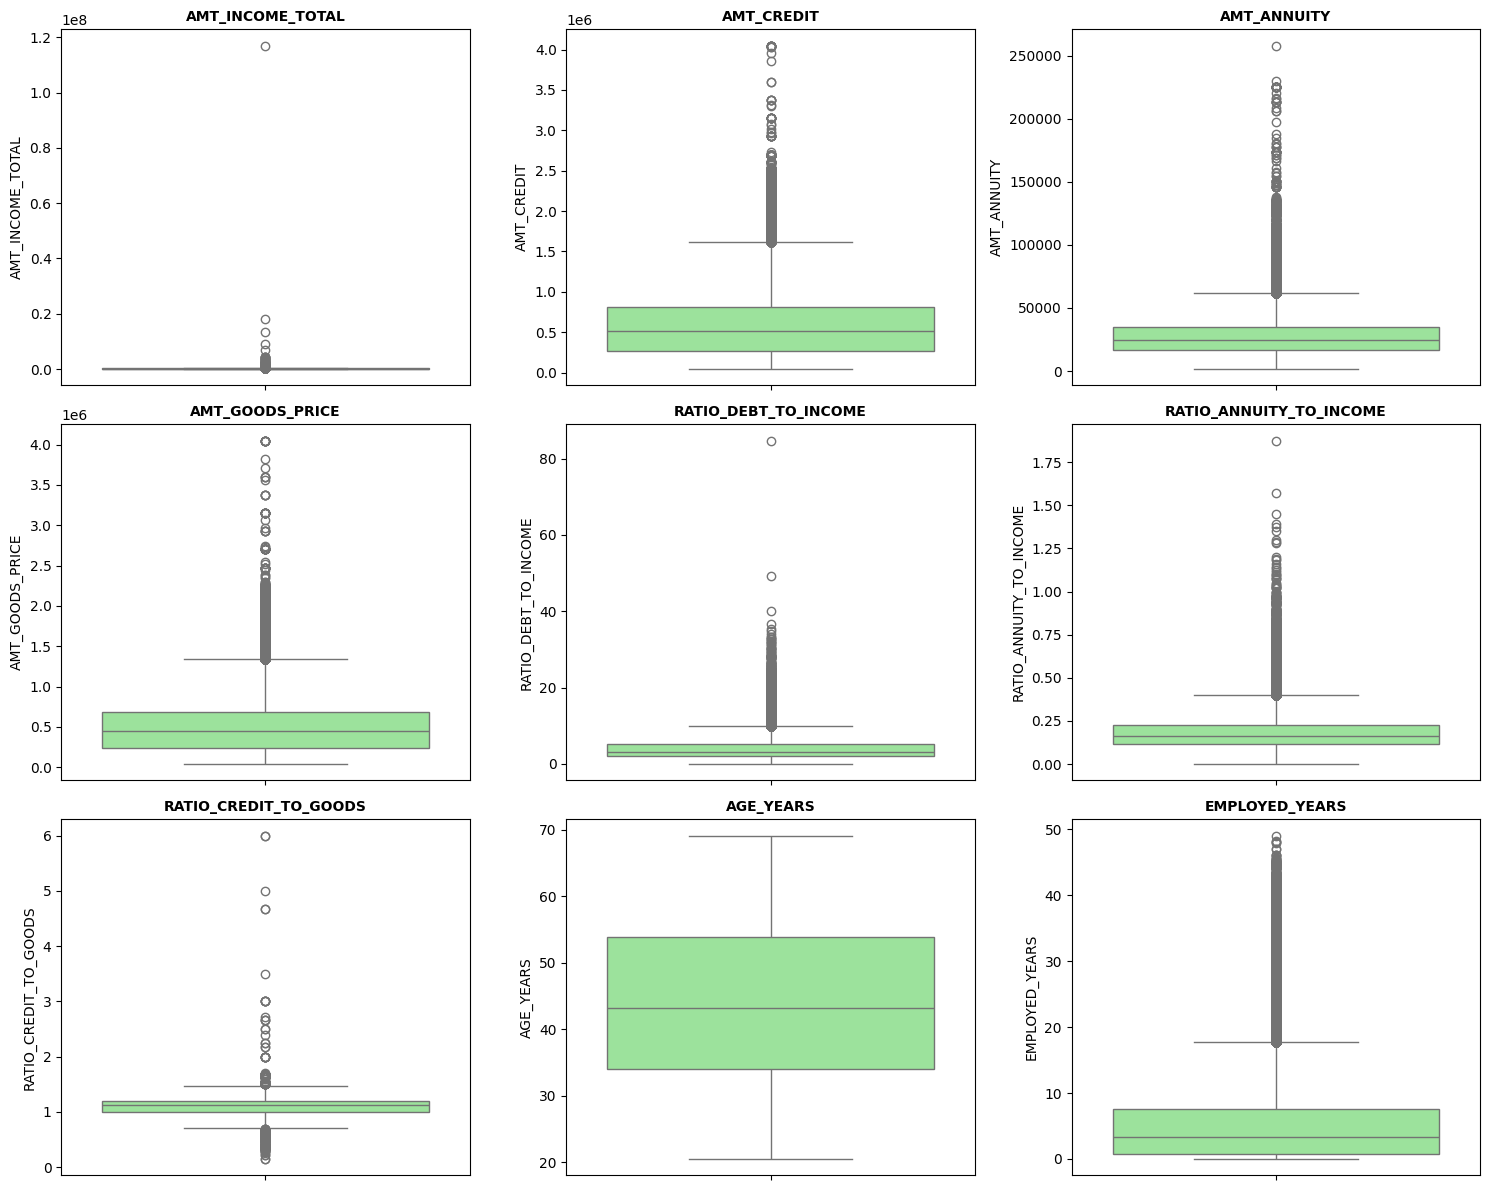

Max values (checking for known extreme outliers):
  AMT_INCOME_TOTAL: max = 117,000,000.00
  AMT_CREDIT: max = 4,050,000.00
  AMT_ANNUITY: max = 258,025.50
  AMT_GOODS_PRICE: max = 4,050,000.00
  RATIO_DEBT_TO_INCOME: max = 84.74
  RATIO_ANNUITY_TO_INCOME: max = 1.88
  RATIO_CREDIT_TO_GOODS: max = 6.00
  AGE_YEARS: max = 69.12
  EMPLOYED_YEARS: max = 49.07


In [21]:
# Boxplots for key numeric columns most likely to have extreme outliers
key_numeric_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'RATIO_DEBT_TO_INCOME', 'RATIO_ANNUITY_TO_INCOME', 'RATIO_CREDIT_TO_GOODS',
    'AGE_YEARS', 'EMPLOYED_YEARS'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(key_numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print actual extreme values for reference
print("Max values (checking for known extreme outliers):")
for col in key_numeric_cols:
    print(f"  {col}: max = {df[col].max():,.2f}")

In [22]:
# Investigate the extreme income outlier
income_threshold = 10_000_000  # anything above 10M is almost certainly a data error at this income level
outlier_rows = df[df['AMT_INCOME_TOTAL'] > income_threshold]

print(f"Rows with income > {income_threshold:,}: {len(outlier_rows)}")
print(outlier_rows[['SK_ID_CURR', 'AMT_INCOME_TOTAL', 'TARGET']])

# For context: what does a "normal" high income look like?
print(f"\n99.9th percentile income: {df['AMT_INCOME_TOTAL'].quantile(0.999):,.2f}")
print(f"99th percentile income: {df['AMT_INCOME_TOTAL'].quantile(0.99):,.2f}")
print(f"Median income: {df['AMT_INCOME_TOTAL'].median():,.2f}")

Rows with income > 10,000,000: 3
        SK_ID_CURR  AMT_INCOME_TOTAL  TARGET
12840       114967       117000000.0       1
203689      336147        18000090.0       0
246854      385674        13500000.0       0

99.9th percentile income: 900,000.00
99th percentile income: 472,500.00
Median income: 147,150.00


In [23]:
# Removing the extreme income outliers (data entry errors, not real values)
df = df[df['AMT_INCOME_TOTAL'] <= income_threshold].reset_index(drop=True)
print(f"New row count: {len(df):,}")
print(f"New max income: {df['AMT_INCOME_TOTAL'].max():,.2f}")

New row count: 307,504
New max income: 9,000,000.00


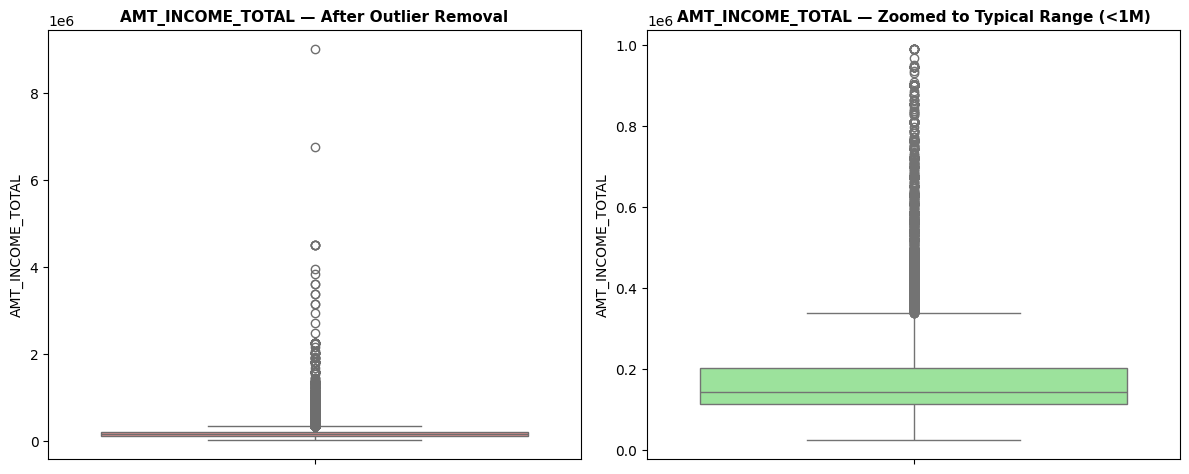

In [24]:
# Confirm the income outlier removal visually — before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['AMT_INCOME_TOTAL'], ax=axes[0], color='lightcoral')
axes[0].set_title('AMT_INCOME_TOTAL — After Outlier Removal', fontsize=11, fontweight='bold')

sns.boxplot(y=df[df['AMT_INCOME_TOTAL'] <= 1_000_000]['AMT_INCOME_TOTAL'], ax=axes[1], color='lightgreen')
axes[1].set_title('AMT_INCOME_TOTAL — Zoomed to Typical Range (<1M)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Exploring Feature Relationships to Default

With a fully numeric, clean dataset, the next step is to look at which features show the
strongest relationship with the TARGET (default) outcome — first visually with a correlation
heatmap, then statistically with a Chi-Square test. No features are removed at this stage; this
is purely diagnostic, feeding into the model training and later the feature-selection voting
step.

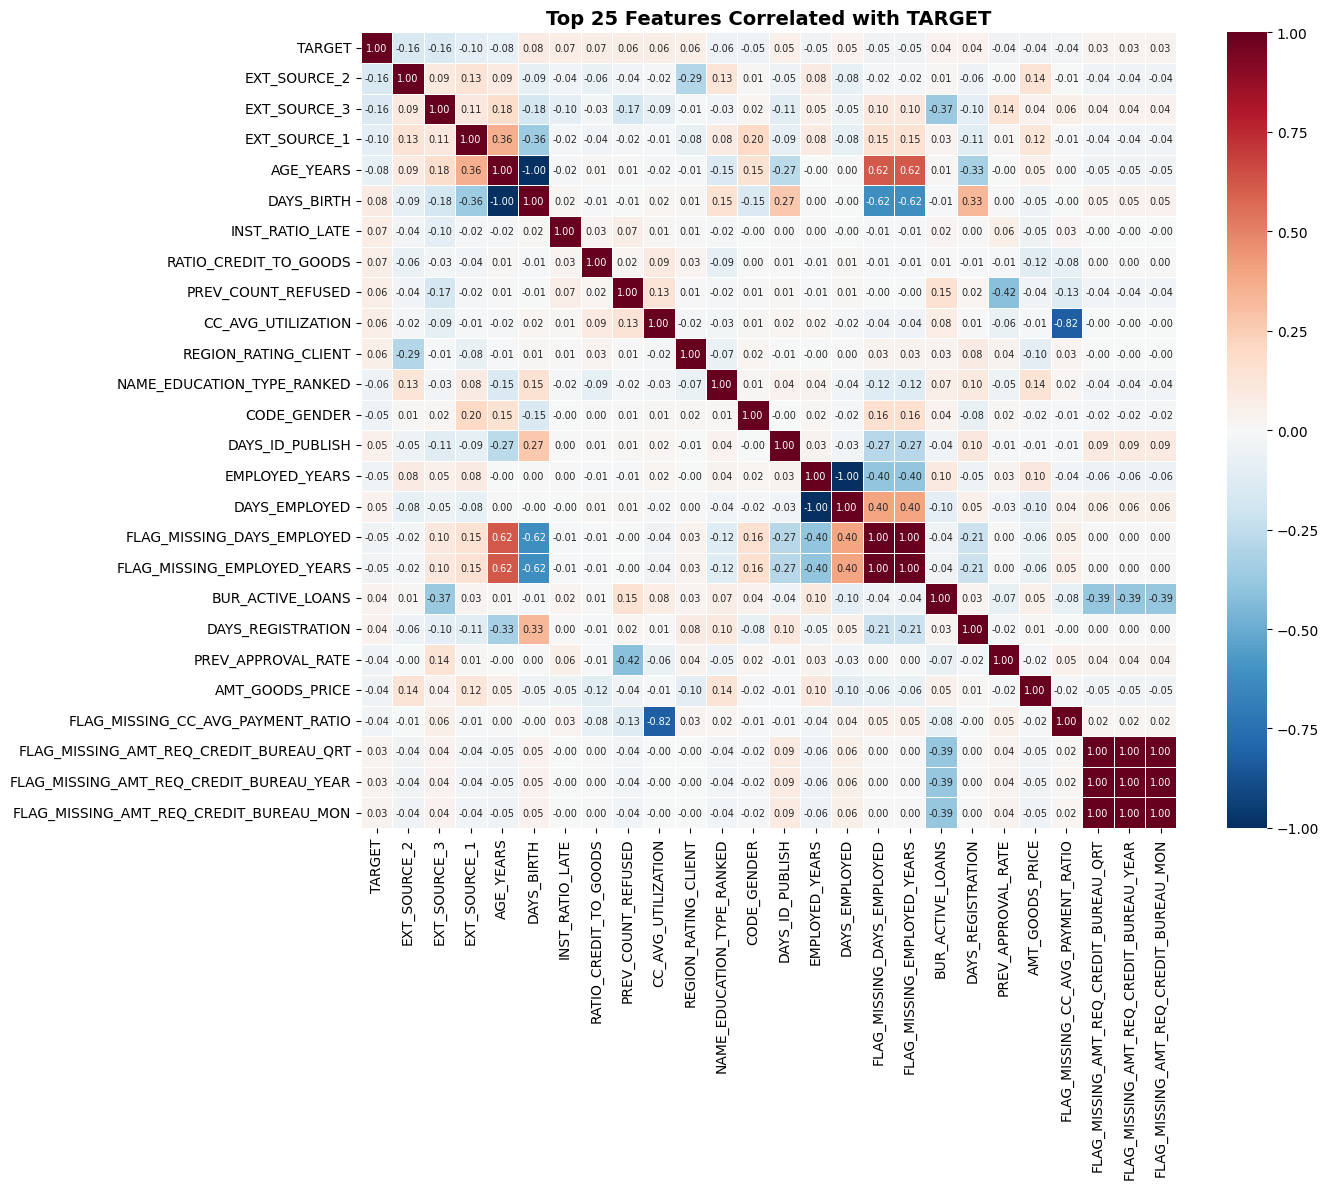

In [25]:
# Correlation heatmap — showing only the top ~25 features most correlated with TARGET
# so it's actually readable (full 197x197 would be illegible in a video)

numeric_df = df.select_dtypes(include=[np.number])
top_corr_features = numeric_df.corr()['TARGET'].abs().sort_values(ascending=False).head(26).index
# 26 because TARGET itself will be included, giving me 25 real features + TARGET

plt.figure(figsize=(14, 12))
sns.heatmap(
    numeric_df[top_corr_features].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    annot_kws={'size': 7}, linewidths=0.5
)
plt.title('Top 25 Features Correlated with TARGET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Pearson correlation only captures straight-line relationships, so any feature with a non-linear or threshold effect could be under-ranked here — that's part of why the final feature selection isn't based on correlation alone, but on five different methods that each catch different kinds of patterns.

**Troubleshooting note:** my first attempt at the Chi-Square test below fails. I left the error in to document the debugging process rather than silently swapping in the fixed version. The error is a `TypeError` from subtracting string values - I traced it back to `NAME_EDUCATION_TYPE` still sitting in the dataframe as raw text alongside the numeric `NAME_EDUCATION_TYPE_RANKED` column I created earlier. I never dropped the original text column after ranking it, so Chi-Square tried to do math on strings. I diagnose and fix this in the next two cells.

In [26]:
from sklearn.feature_selection import chi2

# Chi-square needs non-negative values, so shift each column to start at 0
X_all = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y_all = df['TARGET']

X_chi = X_all.apply(lambda col: col - col.min())
chi_scores, chi_pvalues = chi2(X_chi, y_all)

chi_results = pd.DataFrame({
    'Feature': X_all.columns,
    'Chi2_Score': chi_scores,
    'p_value': chi_pvalues
}).sort_values('Chi2_Score', ascending=False)

print("Top 20 features by Chi-Square score:")
print(chi_results.head(20).to_string(index=False))

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [27]:
# Find any remaining non-numeric columns
remaining_object_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Remaining text columns:", remaining_object_cols)

Remaining text columns: ['NAME_EDUCATION_TYPE']


In [28]:
df = df.drop(columns=['NAME_EDUCATION_TYPE'])
print("Remaining text columns:", df.select_dtypes(include=['object']).columns.tolist())

Remaining text columns: []


**Second error encountered:** after dropping `NAME_EDUCATION_TYPE`, re-running Chi-Square produced a different error: `numpy boolean subtract... not supported`. This came from `pd.get_dummies()` creating `True`/`False` boolean columns instead of 0/1 integers (a change in newer pandas versions). Booleans can't be subtracted, which is what my Chi-Square shift step needs to do. I convert every boolean column to an integer below before trying Chi-Square again.

In [29]:
# Check for boolean columns (created by get_dummies) — these need to become 0/1 integers
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
print(f"Boolean columns found: {len(bool_cols)}")

df[bool_cols] = df[bool_cols].astype(int)

# Confirm no more bool or object columns remain
print("Remaining non-numeric columns:", df.select_dtypes(exclude=[np.number]).columns.tolist())

Boolean columns found: 97
Remaining non-numeric columns: []


In [30]:
# Chi-square needs non-negative values, so shift each column to start at 0
X_all = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y_all = df['TARGET']
X_chi = X_all.apply(lambda col: col - col.min())
chi_scores, chi_pvalues = chi2(X_chi, y_all)
chi_results = pd.DataFrame({
    'Feature': X_all.columns,
    'Chi2_Score': chi_scores,
    'p_value': chi_pvalues
}).sort_values('Chi2_Score', ascending=False)
print("Top 20 features by Chi-Square score:")
print(chi_results.head(20).to_string(index=False))

Top 20 features by Chi-Square score:
              Feature   Chi2_Score  p_value
      AMT_GOODS_PRICE 1.322385e+08      0.0
           AMT_CREDIT 8.292647e+07      0.0
  BUR_MAX_OVERDUE_AMT 1.391675e+07      0.0
     AMT_INCOME_TOTAL 1.039628e+07      0.0
  PREV_AVG_CREDIT_AMT 6.441530e+06      0.0
           DAYS_BIRTH 3.899610e+06      0.0
     PREV_AVG_ANNUITY 1.626716e+06      0.0
      DAYS_ID_PUBLISH 4.414717e+05      0.0
          AMT_ANNUITY 4.155769e+05      0.0
       BUR_TOTAL_DEBT 3.432170e+05      0.0
    DAYS_REGISTRATION 3.417010e+05      0.0
        DAYS_EMPLOYED 2.174562e+05      0.0
 CC_AVG_PAYMENT_RATIO 3.881378e+04      0.0
 BURBAL_MONTHS_CLOSED 2.675725e+04      0.0
  BURBAL_TOTAL_MONTHS 2.542244e+04      0.0
INST_AVG_UNDERPAYMENT 1.904010e+04      0.0
            AGE_YEARS 1.148865e+04      0.0
          POS_MAX_DPD 1.133215e+04      0.0
 BUR_AVG_DAYS_OVERDUE 9.427652e+03      0.0
          POS_AVG_DPD 7.778928e+03      0.0


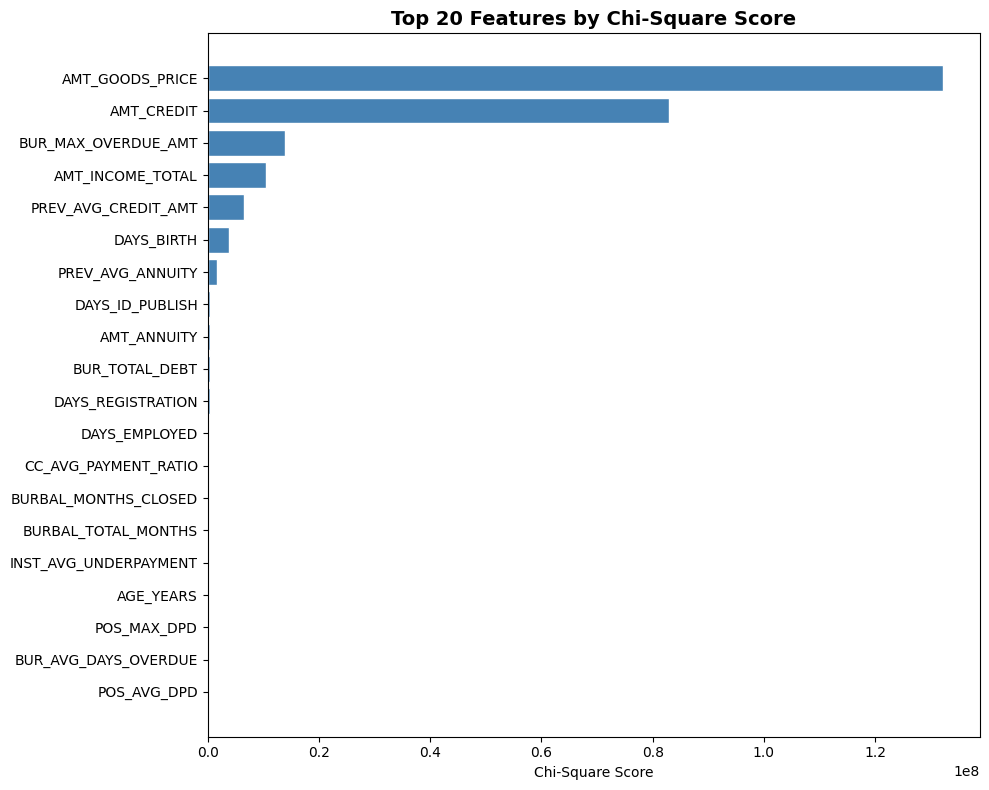

In [31]:
# Chi-Square results as a horizontal bar chart
top_chi = chi_results.head(20).sort_values('Chi2_Score', ascending=True)  # ascending for horizontal bar order

plt.figure(figsize=(10, 8))
plt.barh(top_chi['Feature'], top_chi['Chi2_Score'], color='steelblue', edgecolor='white')
plt.xlabel('Chi-Square Score')
plt.title('Top 20 Features by Chi-Square Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Chi-square ranks large-magnitude dollar columns highest, which is a known scale sensitivity of the test on continuous data — this is one of the reasons I'm using five different methods rather than relying on any single one.

## 7. Baseline Model Training (Full Feature Set)

Before applying any feature selection, three models are trained on the complete feature set to
establish a baseline: Naive Bayes, Decision Tree, and Random Forest. All three use an identical
80/20 stratified train-test split and the same random seed, so any performance differences
reflect the models themselves, not differences in the data they saw. `class_weight='balanced'`
is used where supported to account for the roughly 92:8 class imbalance between repaid and
defaulted applicants.

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"\nTraining class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Training set: 246,003 rows, 194 features
Test set: 61,501 rows

Training class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Test class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


## 7.1 Testing for Multicollinearity (Justifying the Exclusion of Logistic Regression)

Logistic Regression was considered as a sixth feature-ranking/modeling method, since it is a
standard baseline in credit-scoring literature. However, Logistic Regression assumes low
multicollinearity between features — a real concern here, since several features are
engineered directly from the same underlying columns (e.g. the debt, annuity, and goods-price
ratios all derive from AMT_INCOME_TOTAL, AMT_CREDIT, and AMT_GOODS_PRICE). Variance Inflation
Factor (VIF) is used to test this directly before deciding whether to include Logistic
Regression. A VIF above 10 is generally considered evidence of serious multicollinearity.

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF requires a clean numeric matrix with no missing values — X_train already qualifies
# Checking a representative sample of financial/engineered columns most likely to be correlated
vif_check_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'RATIO_DEBT_TO_INCOME', 'RATIO_ANNUITY_TO_INCOME', 'RATIO_CREDIT_TO_GOODS',
    'AGE_YEARS', 'DAYS_BIRTH', 'EMPLOYED_YEARS', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

X_vif = X_train[vif_check_cols].copy()

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== VARIANCE INFLATION FACTOR (VIF) CHECK ===")
print(vif_data.to_string(index=False))
print("\nVIF > 10 indicates serious multicollinearity.")

=== VARIANCE INFLATION FACTOR (VIF) CHECK ===
                Feature        VIF
             DAYS_BIRTH        inf
              AGE_YEARS        inf
          DAYS_EMPLOYED        inf
         EMPLOYED_YEARS        inf
             AMT_CREDIT 196.338624
        AMT_GOODS_PRICE 162.924176
RATIO_ANNUITY_TO_INCOME  46.807767
            AMT_ANNUITY  41.977259
   RATIO_DEBT_TO_INCOME  39.122867
  RATIO_CREDIT_TO_GOODS  34.114391
           EXT_SOURCE_1  16.461068
           EXT_SOURCE_3  10.060807
       AMT_INCOME_TOTAL   9.382214
           EXT_SOURCE_2   8.649247

VIF > 10 indicates serious multicollinearity.


### Conclusion: Logistic Regression Excluded

The VIF results confirm severe multicollinearity across the feature set. DAYS_BIRTH/AGE_YEARS
and DAYS_EMPLOYED/EMPLOYED_YEARS returned infinite VIF, since each pair is a direct linear
transformation of the other and carries no independent information. AMT_CREDIT (196.3) and
AMT_GOODS_PRICE (162.9) are also severely inflated, consistent with the engineered ratio
features (RATIO_CREDIT_TO_GOODS, RATIO_DEBT_TO_INCOME, RATIO_ANNUITY_TO_INCOME) being derived
directly from them. 11 of the 14 tested features exceed the VIF > 10 threshold for serious
multicollinearity.

Based on this evidence, **Logistic Regression is excluded** from both the feature-selection
voting and the model comparison. Its coefficient estimates would be unstable and difficult to
interpret under this level of multicollinearity, undermining the exact interpretability benefit
that would have justified including it. The feature-selection voting instead relies on five
methods (Pearson Correlation, Chi-Square, Naive Bayes, Decision Tree, Random Forest) that do
not share this assumption.

In [34]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
nb_proba = nb_model.predict_proba(X_test)[:, 1]

print("Naive Bayes trained.")

Naive Bayes trained.


In [35]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree trained.")

Decision Tree trained.


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained.")

Random Forest trained.


## 8. Baseline Model Evaluation (Full Feature Set)

With all three models trained on the identical train/test split and the complete 194-feature
set, their raw performance is compared using confusion matrices and a full metrics table
(Accuracy, Precision, Recall, FPR, F1, F2, AUC-ROC). Random Forest produced the strongest
overall performance (AUC-ROC = 0.75), followed by Decision Tree (0.71), with Naive Bayes
performing closest to random guessing (0.60) — consistent with its Gaussian-distribution
assumption being violated by the dataset's heavily skewed financial features.

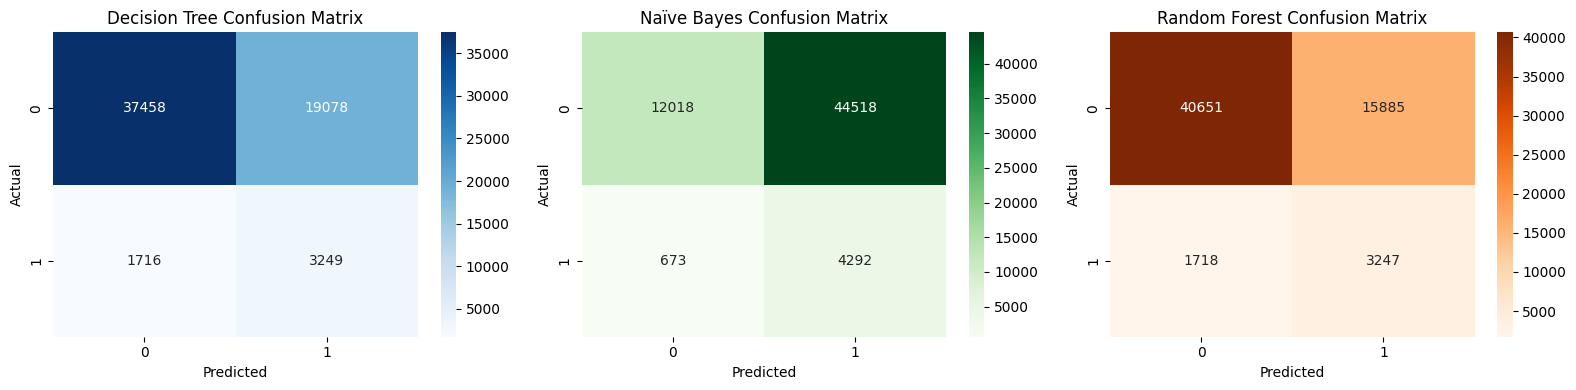

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Decision Tree Confusion Matrix')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Naïve Bayes Confusion Matrix')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Oranges', ax=ax3)
ax3.set_title('Random Forest Confusion Matrix')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')

plt.tight_layout()
plt.show()

--- BASELINE MODEL COMPARISON (Full Feature Set) ---
               Accuracy  Precision  Recall     FPR  F1-Score  F2-Score  \
Decision Tree    0.6619     0.1455  0.6544  0.3374    0.2381    0.3851   
Naive Bayes      0.2652     0.0879  0.8645  0.7874    0.1596    0.3125   
Random Forest    0.7138     0.1697  0.6540  0.2810    0.2695    0.4164   

               AUC-ROC  
Decision Tree   0.7139  
Naive Bayes     0.6018  
Random Forest   0.7535  


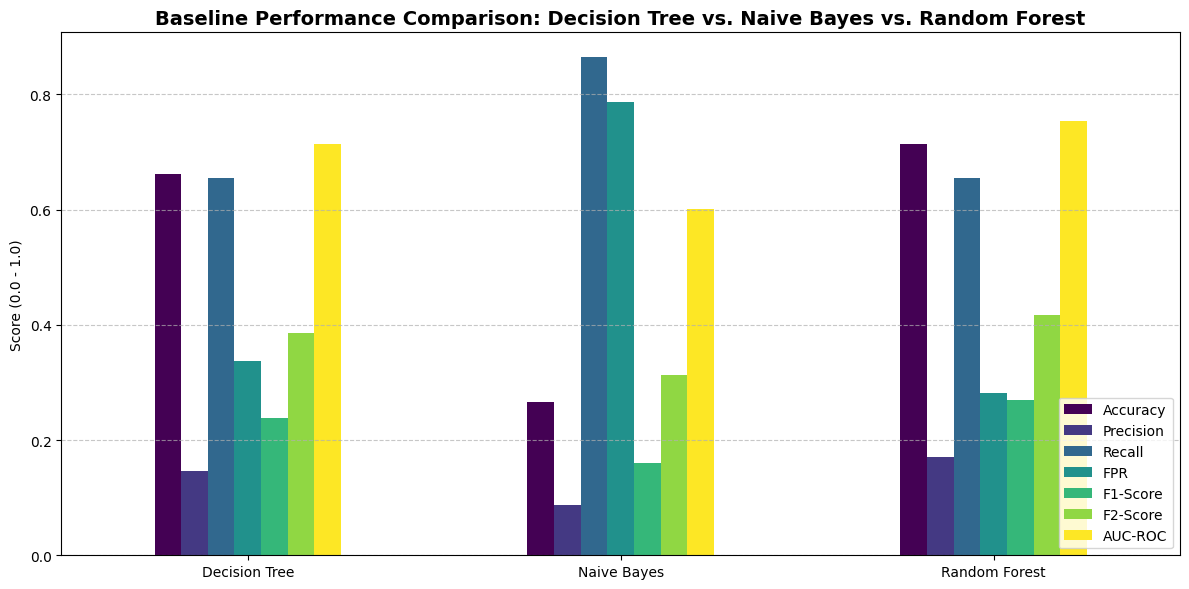

In [38]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score)

def get_metrics_dict(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'FPR': (confusion_matrix(y_true, y_pred)[0, 1]
                / confusion_matrix(y_true, y_pred)[0, :].sum()),
        'F1-Score': f1_score(y_true, y_pred),
        'F2-Score': fbeta_score(y_true, y_pred, beta=2),
        'AUC-ROC': roc_auc_score(y_true, y_proba)
    }

comparison_data = {
    'Decision Tree': get_metrics_dict(y_test, dt_preds, dt_proba),
    'Naive Bayes':   get_metrics_dict(y_test, nb_preds, nb_proba),
    'Random Forest': get_metrics_dict(y_test, rf_preds, rf_proba)
}

df_compare = pd.DataFrame(comparison_data).T

print("--- BASELINE MODEL COMPARISON (Full Feature Set) ---")
print(df_compare.round(4))

df_compare.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Baseline Performance Comparison: Decision Tree vs. Naive Bayes vs. Random Forest',
          fontsize=14, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 9. Risk Tier Breakdown (Baseline Random Forest)

Since RQ2 asks for a 4-tier risk assignment (Low / Medium / High / Decline) rather than a
simple yes/no prediction, the best-performing baseline model's predicted default probabilities
are binned into four tiers. Because the true outcome only exists as a binary label
(repaid/defaulted), this is not a 4x4 confusion matrix — it is a 4x2 table showing the actual
outcome distribution within each predicted risk tier, which is the standard way a real risk
model is evaluated for business use.

In [39]:
# Same binning as before, but with range values shown directly in the labels for clarity
risk_bins = [0, 0.10, 0.25, 0.40, 1.0]
risk_labels = ['Low Risk (0-10%)', 'Medium Risk (10-25%)', 'High Risk (25-40%)', 'Decline (40%+)']

risk_tiers = pd.cut(rf_proba, bins=risk_bins, labels=risk_labels, include_lowest=True)

tier_breakdown = pd.crosstab(risk_tiers, y_test.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
tier_breakdown.columns = ['Repaid (0)', 'Defaulted (1)']

# Fill in 0 for any tier with no applicants, instead of leaving it as NaN
tier_breakdown = tier_breakdown.reindex(risk_labels, fill_value=0)

tier_breakdown['Total Applicants'] = tier_breakdown.sum(axis=1)
tier_breakdown['Actual Default Rate'] = (tier_breakdown['Defaulted (1)'] / tier_breakdown['Total Applicants']).round(4)

print("=== BASELINE RANDOM FOREST — RISK TIER BREAKDOWN ===")
print(tier_breakdown)

=== BASELINE RANDOM FOREST — RISK TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)               0              0                 0   
Medium Risk (10-25%)        1221              9              1230   
High Risk (25-40%)         21447            530             21977   
Decline (40%+)             33868           4426             38294   

                      Actual Default Rate  
Risk Tier                                  
Low Risk (0-10%)                      NaN  
Medium Risk (10-25%)               0.0073  
High Risk (25-40%)                 0.0241  
Decline (40%+)                     0.1156  


**Finding:** the Low Risk (0-10%) tier comes back completely empty - no applicant in the test set received a Random Forest probability below 10%. This isn't a bug in my binning; it's a real side effect of `class_weight='balanced'`, which I used to make the model treat the minority (default) class as more important during training given the ~92:8 imbalance. That correction systematically pushes predicted probabilities upward across the board, so a raw score from this model doesn't yet equal a true real-world default probability. The tier ranking is still meaningful, since the actual default rate climbs steadily from Medium (0.73%) to High (2.41%) to Decline (11.56%) - but calibrating these raw scores into trustworthy percentages (e.g. with CalibratedClassifierCV) is a planned Milestone 4 step, not something this baseline model does yet.

## 10. Consensus Feature Selection (5-Method Voting)

To move from the full 194-feature baseline to a leaner, more interpretable model, five
independent feature-ranking methods are combined: Pearson Correlation, Chi-Square, Naive
Bayes permutation importance, Decision Tree importance, and Random Forest importance. Features
are kept only if a majority of methods agree they matter, which also naturally limits the
influence of any single method's weaknesses (for example, Naive Bayes' rankings, given its
near-random overall performance) on the final feature set. The resulting consensus features are
then used to retrain Random Forest — the strongest baseline model — to produce an optimized
model for direct before/after comparison.

In [40]:
# Each method nominates its top 65 features (out of 194) toward the consensus vote
TOP_N = 65

# 1. Pearson Correlation with TARGET
corr_scores = X_train.corrwith(y_train).abs().sort_values(ascending=False)
list_corr = corr_scores.head(TOP_N).index.tolist()

# 2. Chi-Square (already computed earlier as chi_results)
list_chi = chi_results.head(TOP_N)['Feature'].tolist()

# 3. Decision Tree importance (from the baseline Decision Tree I already trained)
dt_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
list_dt = dt_importances.sort_values(ascending=False).head(TOP_N).index.tolist()

# 4. Random Forest importance (from the baseline Random Forest I already trained)
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
list_rf = rf_importances.sort_values(ascending=False).head(TOP_N).index.tolist()

# 5. Naive Bayes permutation importance (from the baseline Naive Bayes I already trained)
from sklearn.inspection import permutation_importance

nb_perm = permutation_importance(nb_model, X_test, y_test, n_repeats=5,
                                  random_state=42, n_jobs=-1)
nb_importances = pd.Series(nb_perm.importances_mean, index=X_train.columns)
list_nb = nb_importances.sort_values(ascending=False).head(TOP_N).index.tolist()

print(f"Correlation top 10: {list_corr[:10]}")
print(f"\nChi-Square top 10: {list_chi[:10]}")
print(f"\nDecision Tree top 10: {list_dt[:10]}")
print(f"\nRandom Forest top 10: {list_rf[:10]}")
print(f"\nNaive Bayes top 10: {list_nb[:10]}")

Correlation top 10: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'DAYS_BIRTH', 'AGE_YEARS', 'RATIO_CREDIT_TO_GOODS', 'INST_RATIO_LATE', 'CC_AVG_UTILIZATION', 'PREV_COUNT_REFUSED', 'REGION_RATING_CLIENT']

Chi-Square top 10: ['AMT_GOODS_PRICE', 'AMT_CREDIT', 'BUR_MAX_OVERDUE_AMT', 'AMT_INCOME_TOTAL', 'PREV_AVG_CREDIT_AMT', 'DAYS_BIRTH', 'PREV_AVG_ANNUITY', 'DAYS_ID_PUBLISH', 'AMT_ANNUITY', 'BUR_TOTAL_DEBT']

Decision Tree top 10: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'INST_RATIO_LATE', 'RATIO_CREDIT_TO_GOODS', 'BUR_AVG_UTILIZATION', 'CODE_GENDER', 'DAYS_BIRTH', 'AMT_ANNUITY', 'CC_AVG_UTILIZATION']

Random Forest top 10: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'BUR_AVG_UTILIZATION', 'RATIO_CREDIT_TO_GOODS', 'AGE_YEARS', 'DAYS_BIRTH', 'NAME_EDUCATION_TYPE_RANKED', 'EMPLOYED_YEARS', 'DAYS_EMPLOYED']

Naive Bayes top 10: ['DAYS_EMPLOYED', 'DAYS_BIRTH', 'DAYS_REGISTRATION', 'AMT_CREDIT', 'DAYS_ID_PUBLISH', 'BURBAL_TOTAL_MONTHS', 'AMT_GOODS_PRICE', 'INST_TOTAL_RECORDS'

In [41]:
# Build the voting scoreboard: 1 vote per method a feature appears in
all_methods = {
    'Correlation': list_corr,
    'Chi-Square': list_chi,
    'Decision Tree': list_dt,
    'Random Forest': list_rf,
    'Naive Bayes': list_nb
}

votes = pd.DataFrame(index=X_train.columns)
for method, feat_list in all_methods.items():
    votes[method] = votes.index.isin(feat_list).astype(int)

votes['Total_Votes'] = votes.sum(axis=1)
votes = votes.sort_values('Total_Votes', ascending=False)

print("=== FEATURE VOTING SCOREBOARD (top 30) ===")
print(votes.head(30))

print("\n=== VOTE COUNT DISTRIBUTION ===")
print(votes['Total_Votes'].value_counts().sort_index(ascending=False))

=== FEATURE VOTING SCOREBOARD (top 30) ===
                                   Correlation  Chi-Square  Decision Tree  \
CODE_GENDER                                  1           1              1   
DAYS_BIRTH                                   1           1              1   
AMT_CREDIT                                   1           1              1   
AMT_GOODS_PRICE                              1           1              1   
DAYS_EMPLOYED                                1           1              1   
NAME_CONTRACT_TYPE                           1           1              1   
DAYS_REGISTRATION                            1           1              1   
DAYS_ID_PUBLISH                              1           1              1   
REGION_RATING_CLIENT                         1           1              1   
EXT_SOURCE_3                                 1           1              1   
EXT_SOURCE_2                                 1           1              1   
DEF_30_CNT_SOCIAL_CIRCLE         

In [42]:
# Protect the top 10 from each individual method, regardless of vote count,
# then add any additional features that meet the 2+ vote consensus threshold
TOP_PROTECTED = 10

protected_features = set()
for method_list in [list_corr, list_chi, list_dt, list_rf, list_nb]:
    protected_features.update(method_list[:TOP_PROTECTED])

print(f"Protected features (top {TOP_PROTECTED} from each of 5 methods, deduplicated): {len(protected_features)}")

CONSENSUS_THRESHOLD = 2
consensus_features = set(votes[votes['Total_Votes'] >= CONSENSUS_THRESHOLD].index.tolist())

final_feature_selection = sorted(protected_features | consensus_features)

print(f"Consensus features (>= {CONSENSUS_THRESHOLD} votes): {len(consensus_features)}")
print(f"Final combined feature set (protected + consensus): {len(final_feature_selection)}")
print(f"Percentage of original 194 retained: {len(final_feature_selection)/194:.1%}")
print(f"\nFinal feature list:")
print(final_feature_selection)

Protected features (top 10 from each of 5 methods, deduplicated): 29
Consensus features (>= 2 votes): 89
Final combined feature set (protected + consensus): 89
Percentage of original 194 retained: 45.9%

Final feature list:
['AGE_YEARS', 'AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'BURBAL_MONTHS_CLOSED', 'BURBAL_MONTHS_OVERDUE', 'BURBAL_TOTAL_MONTHS', 'BUR_ACTIVE_LOANS', 'BUR_AVG_DAYS_OVERDUE', 'BUR_AVG_UTILIZATION', 'BUR_MAX_OVERDUE_AMT', 'BUR_TOTAL_DEBT', 'BUR_TOTAL_LOANS', 'BUR_TOTAL_PROLONGED', 'CC_AVG_PAYMENT_RATIO', 'CC_AVG_UTILIZATION', 'CC_MAX_DPD', 'CC_TOTAL_CARDS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'CODE_GENDER', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EMPLOYED_YEARS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_MON', 'FLAG_MISSING_AMT_REQ

To avoid discarding a feature that one method considers highly important even without broader agreement, the top 10 features from each individual method were protected from elimination regardless of vote count, in addition to the standard 2+ vote consensus threshold.

### Consensus Feature Selection Result

Using a 2-of-5 method consensus threshold, with the top 10 features from each individual
method protected from elimination regardless of vote count, the feature set was reduced from
194 to 89 features (45.9% retained). All 29 protected top-10 features were already present
within the 2+ vote consensus set, confirming that the highest-ranked feature from each method
was independently corroborated by at least one other method. The resulting feature set spans
external credit bureau scores, applicant demographics, bureau/credit-card/installment history
aggregates, and their associated missingness flags — consistent with the behavioral and
demographic indicators identified as most predictive in the correlation and chi-square analysis.

## 11. Optimized Model: Random Forest on Consensus Features

Random Forest was the strongest-performing baseline model (highest Accuracy, Precision, F1,
F2, and AUC-ROC among the three models tested), so it is retrained here on the 89-feature
consensus set produced by the feature-selection voting step, using identical hyperparameters,
random seed, and train/test split as the baseline model. This isolates the effect of feature
selection alone — any change in performance reflects the trimmed feature set, not a different
model configuration.

In [43]:
# Retrain Random Forest (best baseline model) on the consensus feature set
X_train_optimized = X_train[final_feature_selection]
X_test_optimized = X_test[final_feature_selection]

rf_model_optimized = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                             random_state=42, n_jobs=-1)
rf_model_optimized.fit(X_train_optimized, y_train)
rf_preds_optimized = rf_model_optimized.predict(X_test_optimized)
rf_proba_optimized = rf_model_optimized.predict_proba(X_test_optimized)[:, 1]

print("Optimized Random Forest trained on 89 features.")

Optimized Random Forest trained on 89 features.


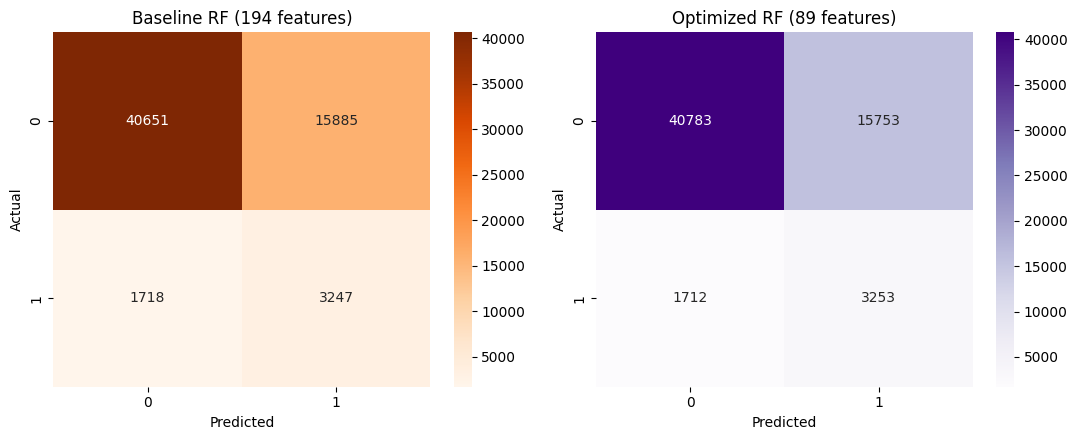

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Oranges', ax=ax1)
ax1.set_title('Baseline RF (194 features)')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds_optimized), annot=True, fmt='d', cmap='Purples', ax=ax2)
ax2.set_title('Optimized RF (89 features)')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

=== RANDOM FOREST: BASELINE vs. OPTIMIZED ===
                            Accuracy  Precision  Recall     FPR  F1-Score  \
Baseline RF (194 features)    0.7138     0.1697  0.6540  0.2810    0.2695   
Optimized RF (89 features)    0.7160     0.1712  0.6552  0.2786    0.2714   

                            F2-Score  AUC-ROC  
Baseline RF (194 features)    0.4164   0.7535  
Optimized RF (89 features)    0.4185   0.7542  


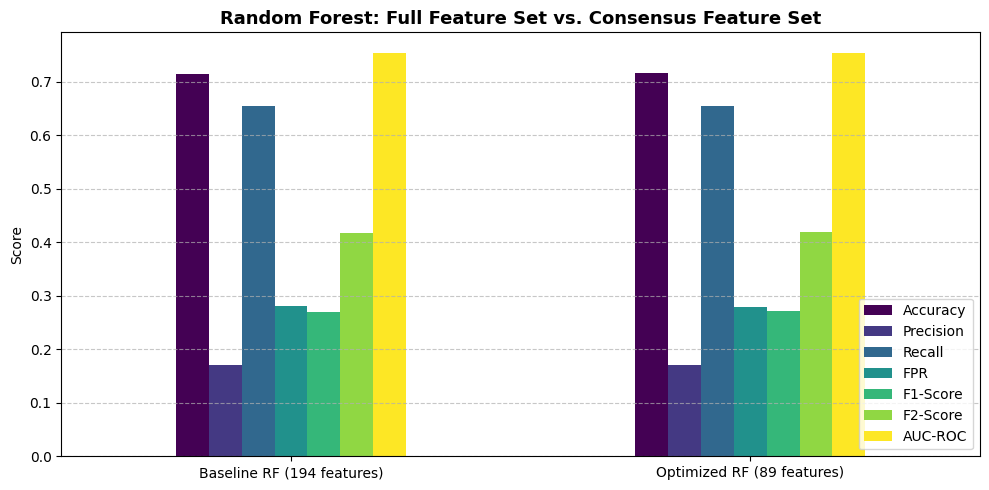

In [45]:
comparison_data = {
    'Baseline RF (194 features)': get_metrics_dict(y_test, rf_preds, rf_proba),
    'Optimized RF (89 features)': get_metrics_dict(y_test, rf_preds_optimized, rf_proba_optimized)
}

df_rf_compare = pd.DataFrame(comparison_data).T
print("=== RANDOM FOREST: BASELINE vs. OPTIMIZED ===")
print(df_rf_compare.round(4))

df_rf_compare.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Random Forest: Full Feature Set vs. Consensus Feature Set', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
risk_bins = [0, 0.10, 0.25, 0.40, 1.0]
risk_labels = ['Low Risk (0-10%)', 'Medium Risk (10-25%)', 'High Risk (25-40%)', 'Decline (40%+)']

def build_tier_table(proba, y_true):
    tiers = pd.cut(proba, bins=risk_bins, labels=risk_labels, include_lowest=True)
    table = pd.crosstab(tiers, y_true.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
    table.columns = ['Repaid (0)', 'Defaulted (1)']
    table = table.reindex(risk_labels, fill_value=0)
    table['Total Applicants'] = table.sum(axis=1)
    table['Actual Default Rate'] = (table['Defaulted (1)'] / table['Total Applicants']).round(4)
    return table

baseline_tiers = build_tier_table(rf_proba, y_test)
optimized_tiers = build_tier_table(rf_proba_optimized, y_test)

print("=== BASELINE RF (194 features) — RISK TIER BREAKDOWN ===")
print(baseline_tiers)
print("\n=== OPTIMIZED RF (89 features) — RISK TIER BREAKDOWN ===")
print(optimized_tiers)

=== BASELINE RF (194 features) — RISK TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)               0              0                 0   
Medium Risk (10-25%)        1221              9              1230   
High Risk (25-40%)         21447            530             21977   
Decline (40%+)             33868           4426             38294   

                      Actual Default Rate  
Risk Tier                                  
Low Risk (0-10%)                      NaN  
Medium Risk (10-25%)               0.0073  
High Risk (25-40%)                 0.0241  
Decline (40%+)                     0.1156  

=== OPTIMIZED RF (89 features) — RISK TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)               0              0                 0   

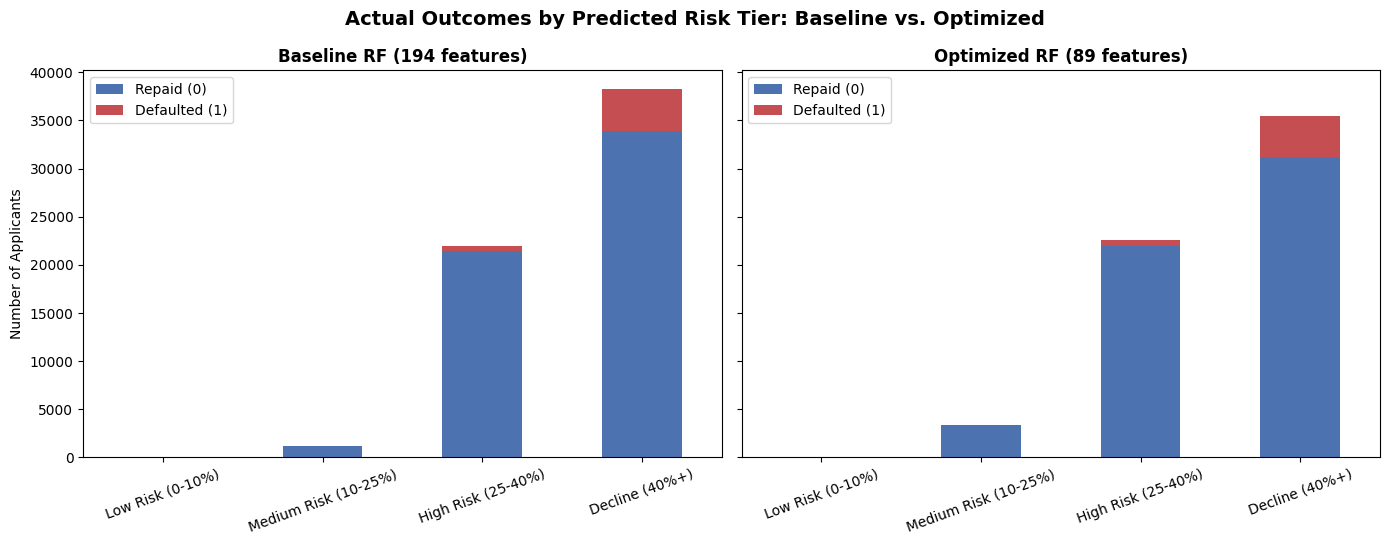

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

baseline_tiers[['Repaid (0)', 'Defaulted (1)']].plot(kind='bar', stacked=True, ax=ax1,
                                                        color=['#4C72B0', '#C44E52'])
ax1.set_title('Baseline RF (194 features)', fontweight='bold')
ax1.set_ylabel('Number of Applicants')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=20)

optimized_tiers[['Repaid (0)', 'Defaulted (1)']].plot(kind='bar', stacked=True, ax=ax2,
                                                         color=['#4C72B0', '#C44E52'])
ax2.set_title('Optimized RF (89 features)', fontweight='bold')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=20)

fig.suptitle('Actual Outcomes by Predicted Risk Tier: Baseline vs. Optimized', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()